# Logistic Regression Model

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [37]:
df=pd.read_csv("customer_churn.csv")

In [38]:
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [39]:
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [40]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


In [41]:
df.dtypes

age                        int64
income                   float64
credit_score             float64
transactions_month         int64
avg_purchase_value       float64
days_since_last_login      int64
tenure_months              int64
num_products               int64
gender                       str
region                       str
churn                      int64
dtype: object

In [42]:
df.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   str    
 9   region                 1000 non-null   str    
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 86.1 KB


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'age'),
  Text(1, 0, 'income'),
  Text(2, 0, 'credit_score'),
  Text(3, 0, 'transactions_month'),
  Text(4, 0, 'avg_purchase_value'),
  Text(5, 0, 'days_since_last_login'),
  Text(6, 0, 'tenure_months'),
  Text(7, 0, 'num_products'),
  Text(8, 0, 'churn')])

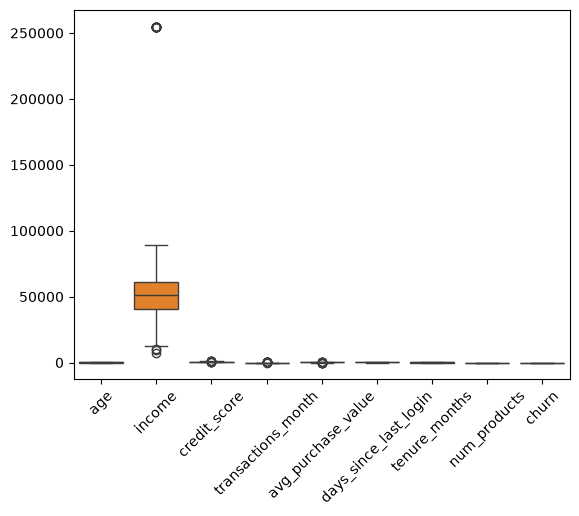

In [45]:
# to check the outliers

sns.boxplot(df)
plt.xticks(rotation=45)

#### Data Preprocessing

In [57]:
# handel the misssin value in the columns usingg the medium

# income column
income_median=df["income"].median()
income_median=round(income_median,2)

# credit_ccore column 
credit_score_median=df['credit_score'].median()
credit_score_median=round(credit_score_median,2)

# transactions_month column

# avg_purchase_value column
avg_purchase_value_median=df["avg_purchase_value"].median()
avg_purchase_value_median=round(avg_purchase_value_median,2)

# handel the missing values
# credit score
df["credit_score"]=df["credit_score"].fillna(credit_score_median)
# income column
df["income"]=df["income"].fillna(income_median)
# avg_purchase_value
df["avg_purchase_value"]=df["avg_purchase_value"].fillna(avg_purchase_value_median)

In [58]:
df.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [61]:
# handel the outliers
num_columns=df[["income","credit_score","avg_purchase_value"]]

for column in num_columns:
    # finding the q1 and q3
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    # find the IQR
    IQR=Q3-Q1

    # find UB and LB
    LB=Q1-1.5*IQR
    UB=Q3+1.5*IQR

    # # find the outliers
    # outlier=df[df[column]<LB | df[column]>UB]

    # handel the outliers
    df[column]=df[column].clip(lower=LB,upper=UB)


<Axes: >

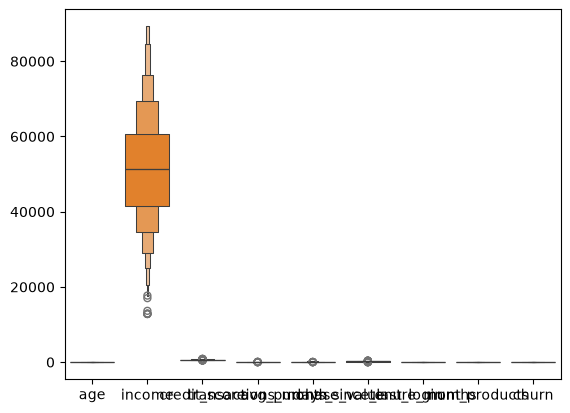

In [62]:
sns.boxenplot(df)

In [64]:
# handel the categorical columns
df["gender"]=df["gender"].replace({"Male":1,"Female":0})

# drop region column
df.drop("region",axis=1,inplace=True)

### Divide the data into x and y

In [66]:
X=df.drop("churn",axis=1)
y=df["churn"]

In [68]:
X.shape

(1000, 9)

In [70]:
y.shape

(1000,)

In [72]:
# spliting into train and test

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [75]:
# model buliding

from sklearn.linear_model import LogisticRegression

LR=LogisticRegression()

# train the model
model=LR.fit(X_train,y_train)

# ?prediction on testing
y_pred=model.predict(X_test)

c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# moedel evalulation

from sklearn.metrics import accuracy_score

# ?find aaccuracy
    
ac=accuracy_score(y_test,y_pred)
print("Accuracy model, ",ac)

Accuracy model,  0.53
